In [ ]:
import torch as t
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification

In [ ]:
# dataset

<Axes: >

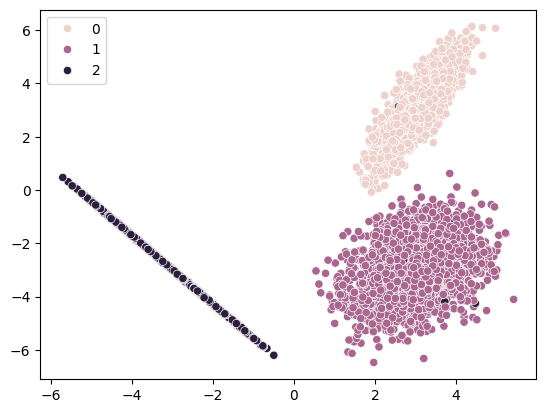

In [ ]:
fv,cv=make_classification(n_samples=10000,n_features=2,n_informative=2,n_redundant=0,random_state=1,n_repeated=0,n_classes=3,class_sep=3,n_clusters_per_class=1)
sns.scatterplot(x=fv[:,0],y=fv[:,1],hue=cv)


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(fv,cv,test_size=0.2,stratify=cv)
x_trainf,x_cv,y_trainf,y_cv=train_test_split(x_train,y_train,test_size=0.2,stratify=y_train)

In [ ]:
"""
train=(x_traif,y_trainf)
cv=(x_cv,y_cv)
test=(x_test,y_test)"""

'\ntrain=(x_traif,y_trainf)\ncv=(x_cv,y_cv)\ntest=(x_test,y_test)'

In [ ]:
from sklearn.preprocessing import StandardScaler
st = StandardScaler()

In [ ]:
x_trains=st.fit_transform(x_trainf)
x_cvs=st.transform(x_cv)
x_tests=st.transform(x_test)

In [ ]:
x_trains=t.from_numpy(x_trains).to(dtype=t.float32)
y_train=t.from_numpy(y_trainf).long()

x_cvs=t.from_numpy(x_cvs).to(dtype=t.float32)
y_cv=t.from_numpy(y_cv).long()

x_tests=t.from_numpy(x_tests).to(dtype=t.float32)
y_test=t.from_numpy(y_test).long()

In [ ]:
class MulitClass(t.nn.Module):
  def __init__(self,n_features):
    super().__init__()

    self.ann=t.nn.Sequential(
        t.nn.Linear(n_features,6),
        t.nn.Sigmoid(),
        t.nn.Linear(6,4),
        t.nn.Sigmoid(),
        t.nn.Linear(4,3),
    )

  def forward(self,data):
    return self.ann(data)

In [ ]:
list(model.parameters())

[Parameter containing:
 tensor([[ 0.6604,  0.6305],
         [ 0.5348, -0.3572],
         [ 0.0462,  0.4504],
         [ 0.0171, -0.4277],
         [-0.2552,  0.3607],
         [-0.0351,  0.5143]], requires_grad=True),
 Parameter containing:
 tensor([-0.5875, -0.0726, -0.5257, -0.5675, -0.3630, -0.1425],
        requires_grad=True),
 Parameter containing:
 tensor([[ 0.0680, -0.2538, -0.2288,  0.0966, -0.2321,  0.3902],
         [-0.3091, -0.3413,  0.0274, -0.0712,  0.2765, -0.2388],
         [ 0.1279, -0.3637,  0.0938, -0.4064,  0.1656, -0.0981],
         [ 0.0236, -0.2435,  0.1417, -0.0611, -0.0197,  0.2492]],
        requires_grad=True),
 Parameter containing:
 tensor([ 0.1683,  0.3015,  0.1110, -0.1458], requires_grad=True),
 Parameter containing:
 tensor([[-0.0457,  0.4769, -0.0116, -0.2449],
         [-0.1573, -0.0623, -0.2252,  0.0749],
         [-0.2693, -0.1083,  0.0245, -0.2898]], requires_grad=True),
 Parameter containing:
 tensor([-0.4860, -0.3898,  0.4233], requires_grad=Tr

In [ ]:
model=MulitClass(2)

# define the loss

loss=t.nn.CrossEntropyLoss()

# define the optimiser
opt=t.optim.SGD(model.parameters(),lr=0.7)

train_loss_d=[]
cv_loss_d=[]

for iter in range(1000):
  model.train()

  predi_t=model(x_trains)

  train_loss=loss(predi_t.squeeze(),y_train)

  opt.zero_grad()

  train_loss.backward()

  opt.step()

  model.eval()

  with t.no_grad():
    predi_cv=model(x_cvs)

    cv_loss=loss(predi_cv,y_cv)

  train_loss_d.append(train_loss.detach().numpy())
  cv_loss_d.append(cv_loss.numpy())

  print("epochs :{}, train_loss :{}, cv_loss :{}".format(iter+1,train_loss,cv_loss))


epochs :1, train_loss :1.1516101360321045, cv_loss :1.1140094995498657
epochs :2, train_loss :1.1139817237854004, cv_loss :1.1023138761520386
epochs :3, train_loss :1.102301836013794, cv_loss :1.098831057548523
epochs :4, train_loss :1.0988304615020752, cv_loss :1.0977013111114502
epochs :5, train_loss :1.0977078676223755, cv_loss :1.0971894264221191
epochs :6, train_loss :1.0972012281417847, cv_loss :1.0968300104141235
epochs :7, train_loss :1.0968456268310547, cv_loss :1.0965040922164917
epochs :8, train_loss :1.0965231657028198, cv_loss :1.0961816310882568
epochs :9, train_loss :1.0962035655975342, cv_loss :1.0958549976348877
epochs :10, train_loss :1.0958797931671143, cv_loss :1.0955212116241455
epochs :11, train_loss :1.0955489873886108, cv_loss :1.0951790809631348
epochs :12, train_loss :1.0952097177505493, cv_loss :1.094827651977539
epochs :13, train_loss :1.0948612689971924, cv_loss :1.094465970993042
epochs :14, train_loss :1.0945026874542236, cv_loss :1.0940929651260376
epoch

In [ ]:
import desicion

In [ ]:
from desicion import plot_decision_boundary

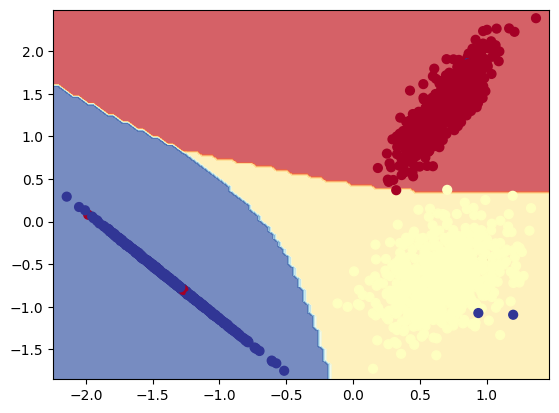

In [ ]:
plot_decision_boundary(model,x_tests,y_test)

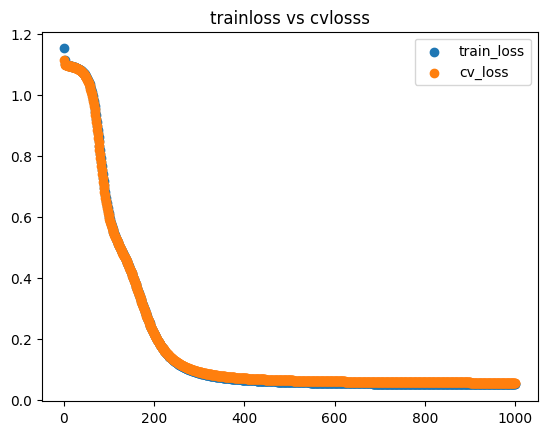

In [ ]:
plt.scatter(range(1,1000+1),train_loss_d,label="train_loss")
plt.scatter(range(1,1000+1),cv_loss_d,label="cv_loss")
plt.title("trainloss vs cvlosss")
plt.legend()
plt.show()

In [ ]:
x_test.shape

(2000, 2)

In [ ]:
t.nn.Softmax

In [ ]:
with t.no_grad():
  pr_test=model(x_tests)
  pr_test=t.softmax(pr_test,dim=1).argmax(dim=1)

pr_test


tensor([0, 0, 0,  ..., 2, 2, 0])

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay,precision_score,recall_score,f1_score,classification_report,log_loss


In [ ]:
accuracy_score(y_test,pr_test)

0.9945

In [ ]:
confusion_matrix(y_test,pr_test
)

array([[661,   2,   5],
       [  1, 666,   0],
       [  1,   2, 662]])

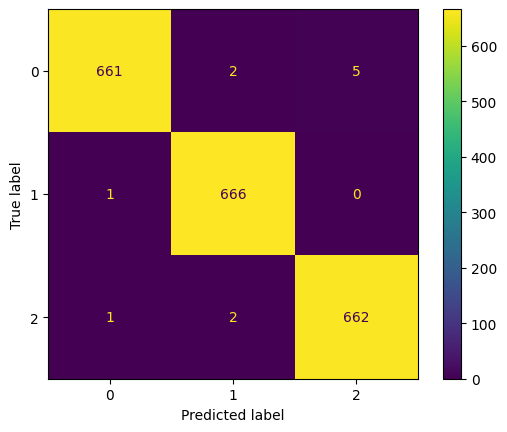

In [ ]:
cmd=ConfusionMatrixDisplay(confusion_matrix(y_test,pr_test))
cmd.plot()

In [ ]:
print(classification_report(y_test,pr_test))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       668
           1       0.99      1.00      1.00       667
           2       0.99      1.00      0.99       665

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



In [ ]:
log_loss(y_test,pr_labeltest)

0.12615278686191028